In [14]:
# Stock Market Analysis
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [15]:
# ============================================================
# LOAD STOCK MARKET DATASET
# ============================================================

from google.colab import files

# Upload CSV file
uploaded = files.upload()

# Get the uploaded file name automatically
file_name = next(iter(uploaded))

# Load dataset
df = pd.read_csv(file_name)

# Convert Date column into proper datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Sort data chronologically
df = df.sort_values("Date").reset_index(drop=True)

print("✅ Dataset loaded successfully!")
print(f"📁 File Name   : {file_name}")
print(f"📊 Rows        : {df.shape[0]:,}")
print(f"📌 Columns     : {df.shape[1]}")
print(f"📅 Start Date  : {df['Date'].min().date()}")
print(f"📅 End Date    : {df['Date'].max().date()}")

Saving stock_data.csv to stock_data.csv
✅ Dataset loaded successfully!
📁 File Name   : stock_data.csv
📊 Rows        : 1,303
📌 Columns     : 7
📅 Start Date  : 2021-01-04
📅 End Date    : 2025-12-31


In [16]:
# ============================================================
#  DATASET OVERVIEW
# ============================================================

print("🔎 Exploring Stock Market Dataset...")
print("─" * 50)

# Display first 5 records
print("\n📌 First 5 Records:")
display(df.head())

# Dataset information
print("\n📋 Dataset Information:")
df.info()

# Check dataset dimensions
print("\n📊 Dataset Shape:")
print(f"   Total Records : {df.shape[0]:,}")
print(f"   Total Columns : {df.shape[1]}")

# Display column names
print("\n🗂️ Available Columns:")
print(list(df.columns))

print("\n✅ Initial dataset exploration completed!")

🔎 Exploring Stock Market Dataset...
──────────────────────────────────────────────────

📌 First 5 Records:


,Date,Open,High,Low,Close,Adj Close,Volume
0,2021-01-04,130.53,132.52,130.21,131.23,131.09,75823408
1,2021-01-05,131.45,133.05,129.30,130.96,130.94,72798364
2,2021-01-06,131.72,134.99,131.24,132.55,132.29,60118810
3,2021-01-07,136.33,138.61,135.35,136.30,136.12,62995077
4,2021-01-08,135.78,138.23,134.61,135.79,135.71,83484773



📋 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1303 non-null   datetime64[ns]
 1   Open       1303 non-null   float64       
 2   High       1303 non-null   float64       
 3   Low        1303 non-null   float64       
 4   Close      1303 non-null   float64       
 5   Adj Close  1303 non-null   float64       
 6   Volume     1303 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 71.4 KB

📊 Dataset Shape:
   Total Records : 1,303
   Total Columns : 7

🗂️ Available Columns:
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

✅ Initial dataset exploration completed!


In [17]:
# ============================================================
# DATASET OVERVIEW
# ============================================================

print("🔎 Exploring Stock Market Dataset...")
print("─" * 50)

print("\n📌 First 5 Records:")
display(df.head())

print("\n📋 Dataset Information:")
df.info()

print("\n📊 Dataset Shape:")
print(f"   Total Records : {df.shape[0]:,}")
print(f"   Total Columns : {df.shape[1]}")

print("\n🗂️ Available Columns:")
print(list(df.columns))

print("\n✅ Initial dataset exploration completed!")

🔎 Exploring Stock Market Dataset...
──────────────────────────────────────────────────

📌 First 5 Records:


,Date,Open,High,Low,Close,Adj Close,Volume
0,2021-01-04,130.53,132.52,130.21,131.23,131.09,75823408
1,2021-01-05,131.45,133.05,129.30,130.96,130.94,72798364
2,2021-01-06,131.72,134.99,131.24,132.55,132.29,60118810
3,2021-01-07,136.33,138.61,135.35,136.30,136.12,62995077
4,2021-01-08,135.78,138.23,134.61,135.79,135.71,83484773



📋 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1303 non-null   datetime64[ns]
 1   Open       1303 non-null   float64       
 2   High       1303 non-null   float64       
 3   Low        1303 non-null   float64       
 4   Close      1303 non-null   float64       
 5   Adj Close  1303 non-null   float64       
 6   Volume     1303 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 71.4 KB

📊 Dataset Shape:
   Total Records : 1,303
   Total Columns : 7

🗂️ Available Columns:
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

✅ Initial dataset exploration completed!


In [18]:
# ============================================================
# DATA QUALITY CHECK & CLEANING
# ============================================================

print("🧹 Checking data quality...")
print("─" * 50)

# Check missing values
missing_values = df.isnull().sum()

print("\n🔍 Missing Values:")
display(missing_values.to_frame(name="Missing Count"))

# Check duplicate records
duplicate_count = df.duplicated().sum()

print(f"\n📑 Duplicate Records : {duplicate_count}")

# Remove duplicate records if any
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("✅ Duplicate records removed.")
else:
    print("✅ No duplicate records found.")

# Check date duplicates
date_duplicates = df["Date"].duplicated().sum()
print(f"📅 Duplicate Dates   : {date_duplicates}")

# Final dataset size
print(f"\n📊 Final Records     : {len(df):,}")
print("✅ Data quality check completed!")

🧹 Checking data quality...
──────────────────────────────────────────────────

🔍 Missing Values:


,Missing Count
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0



📑 Duplicate Records : 0
✅ No duplicate records found.
📅 Duplicate Dates   : 0

📊 Final Records     : 1,303
✅ Data quality check completed!


In [19]:
# ============================================================
# DESCRIPTIVE STATISTICS
# ============================================================

print("📊 Analyzing Stock Price Statistics...")
print("─" * 50)

# Select important numerical columns
price_columns = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]

# Generate statistical summary
statistics = df[price_columns].describe().T

# Add useful additional metrics
statistics["Median"] = df[price_columns].median()
statistics["Range"] = df[price_columns].max() - df[price_columns].min()

print("\n📈 Statistical Summary:")
display(statistics.round(2))

print("\n💡 Key Price Insights:")
print(f"   Highest Closing Price : ${df['Close'].max():,.2f}")
print(f"   Lowest Closing Price  : ${df['Close'].min():,.2f}")
print(f"   Average Closing Price : ${df['Close'].mean():,.2f}")
print(f"   Average Daily Volume  : {df['Volume'].mean():,.0f}")

print("\n✅ Statistical analysis completed!")

📊 Analyzing Stock Price Statistics...
──────────────────────────────────────────────────

📈 Statistical Summary:


,count,mean,std,min,25%,50%,75%,max,Median,Range
Open,"1,303.00",237.67,139.69,105.31,144.62,168.47,299.40,596.59,168.47,491.28
High,"1,303.00",241.37,141.93,107.54,146.64,170.96,303.14,608.62,170.96,501.08
Low,"1,303.00",233.91,137.44,103.11,142.20,166.01,293.54,588.48,166.01,485.37
Close,"1,303.00",237.64,139.68,106.84,144.27,168.21,297.94,595.10,168.21,488.26
Adj Close,"1,303.00",237.40,139.54,106.72,144.15,168.06,297.56,594.19,168.06,487.47
Volume,"1,303.00","76,380,066.25","31,907,585.11","27,417,488.00","57,315,975.00","69,956,645.00","85,852,740.00","373,191,290.00","69,956,645.00","345,773,802.00"



💡 Key Price Insights:
   Highest Closing Price : $595.10
   Lowest Closing Price  : $106.84
   Average Closing Price : $237.64
   Average Daily Volume  : 76,380,066

✅ Statistical analysis completed!


📈 Visualizing Closing Price Trend...
──────────────────────────────────────────────────


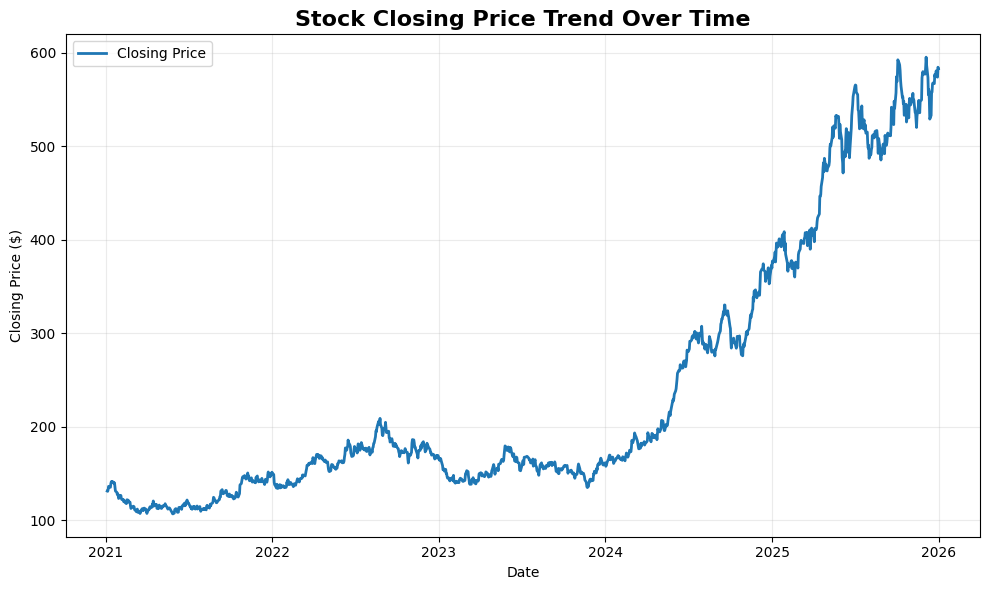


💡 The chart shows how the stock's closing price changed over time.


In [21]:
# ============================================================
# CLOSING PRICE TREND
# ============================================================

print("📈 Visualizing Closing Price Trend...")
print("─" * 50)

plt.figure(figsize=(10, 6))

plt.plot(
    df["Date"],
    df["Close"],
    linewidth=2,
    label="Closing Price"
)

plt.title("Stock Closing Price Trend Over Time", fontsize=16, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")

plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()

plt.show()

print("\n💡 The chart shows how the stock's closing price changed over time.")

In [22]:
# ============================================================
# MOVING AVERAGE ANALYSIS
# ============================================================

print("📊 Calculating Moving Averages...")
print("─" * 50)

# Calculate short-term and medium-term moving averages
df["MA_20"] = df["Close"].rolling(window=20).mean()
df["MA_50"] = df["Close"].rolling(window=50).mean()

print("✅ 20-day Moving Average calculated.")
print("✅ 50-day Moving Average calculated.")

print("\n📌 Latest Moving Average Values:")
print(f"   Closing Price : ${df['Close'].iloc[-1]:,.2f}")
print(f"   20-Day MA     : ${df['MA_20'].iloc[-1]:,.2f}")
print(f"   50-Day MA     : ${df['MA_50'].iloc[-1]:,.2f}")

print("\n💡 Moving averages help identify the underlying stock price trend.")

📊 Calculating Moving Averages...
──────────────────────────────────────────────────
✅ 20-day Moving Average calculated.
✅ 50-day Moving Average calculated.

📌 Latest Moving Average Values:
   Closing Price : $582.78
   20-Day MA     : $567.34
   50-Day MA     : $556.95

💡 Moving averages help identify the underlying stock price trend.


📈 Visualizing Moving Average Trends...
──────────────────────────────────────────────────


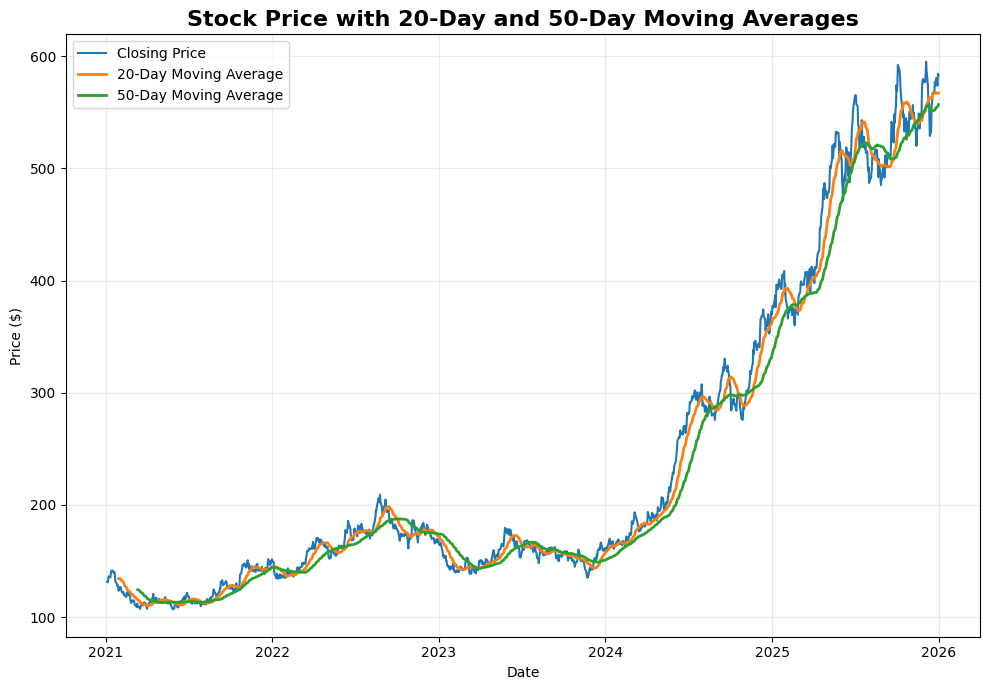


💡 Moving averages smooth short-term price fluctuations
   and help identify the underlying market trend.


In [24]:
# ============================================================
# MOVING AVERAGE TREND VISUALIZATION
# ============================================================

print("📈 Visualizing Moving Average Trends...")
print("─" * 50)

plt.figure(figsize=(10, 7))

plt.plot(
    df["Date"],
    df["Close"],
    linewidth=1.5,
    label="Closing Price"
)

plt.plot(
    df["Date"],
    df["MA_20"],
    linewidth=2,
    label="20-Day Moving Average"
)

plt.plot(
    df["Date"],
    df["MA_50"],
    linewidth=2,
    label="50-Day Moving Average"
)

plt.title(
    "Stock Price with 20-Day and 50-Day Moving Averages",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Price ($)")

plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()

plt.show()

print("\n💡 Moving averages smooth short-term price fluctuations")
print("   and help identify the underlying market trend.")

In [25]:
# ============================================================
# TRADING VOLUME ANALYSIS
# ============================================================

print("📦 Analyzing Trading Volume...")
print("─" * 50)

# Calculate average trading volume
average_volume = df["Volume"].mean()

# Find highest volume day
highest_volume_index = df["Volume"].idxmax()
highest_volume_date = df.loc[highest_volume_index, "Date"]
highest_volume = df.loc[highest_volume_index, "Volume"]

print(f"\n📊 Average Trading Volume : {average_volume:,.0f}")
print(f"🔥 Highest Trading Volume: {highest_volume:,.0f}")
print(f"📅 Highest Volume Date    : {highest_volume_date.strftime('%d %B %Y')}")

print("\n💡 Trading volume indicates the level of market activity")
print("   and can help identify periods of strong investor interest.")

📦 Analyzing Trading Volume...
──────────────────────────────────────────────────

📊 Average Trading Volume : 76,380,066
🔥 Highest Trading Volume: 373,191,290
📅 Highest Volume Date    : 14 August 2023

💡 Trading volume indicates the level of market activity
   and can help identify periods of strong investor interest.


📊 Visualizing Trading Volume...
──────────────────────────────────────────────────


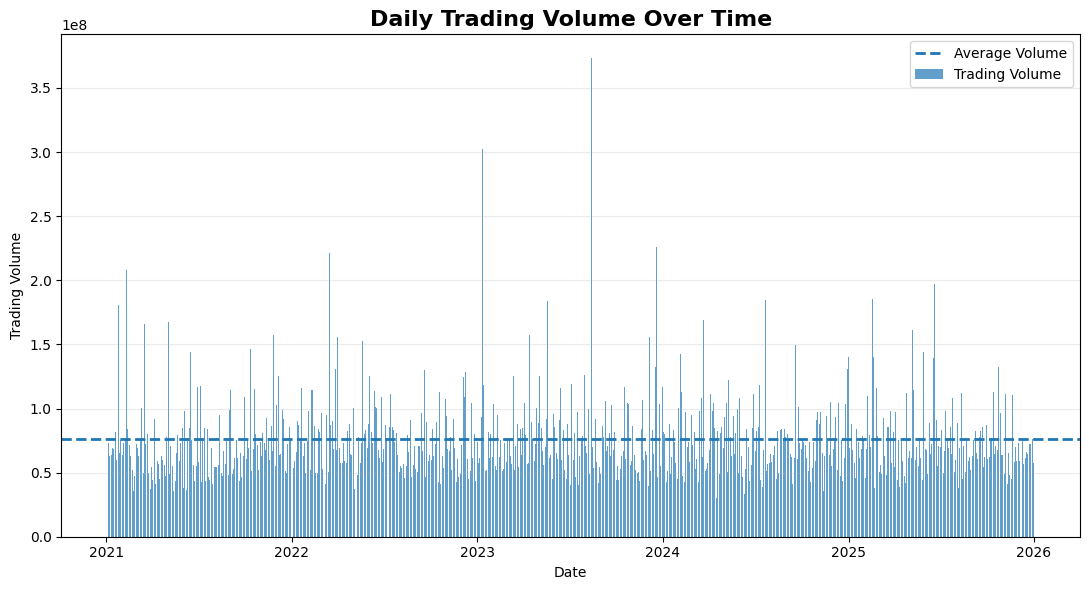


💡 Higher volume indicates stronger market activity,
   while lower volume represents relatively lower activity.


In [27]:
# ============================================================
# TRADING VOLUME VISUALIZATION
# ============================================================

print("📊 Visualizing Trading Volume...")
print("─" * 50)

plt.figure(figsize=(11, 6))

plt.bar(
    df["Date"],
    df["Volume"],
    width=1.0,
    alpha=0.7,
    label="Trading Volume"
)

plt.axhline(
    average_volume,
    linestyle="--",
    linewidth=2,
    label="Average Volume"
)

plt.title(
    "Daily Trading Volume Over Time",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Trading Volume")

plt.grid(True, axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()

plt.show()

print("\n💡 Higher volume indicates stronger market activity,")
print("   while lower volume represents relatively lower activity.")

In [28]:
# ============================================================
# DAILY RETURNS ANALYSIS
# ============================================================

print("📈 Analyzing Daily Stock Returns...")
print("─" * 50)

# Calculate daily percentage return
df["Daily_Return"] = df["Close"].pct_change() * 100

# Calculate key return statistics
average_return = df["Daily_Return"].mean()
highest_return = df["Daily_Return"].max()
lowest_return = df["Daily_Return"].min()
volatility = df["Daily_Return"].std()

print(f"\n📊 Average Daily Return : {average_return:.2f}%")
print(f"🚀 Highest Daily Return : {highest_return:.2f}%")
print(f"📉 Lowest Daily Return  : {lowest_return:.2f}%")
print(f"⚡ Daily Volatility     : {volatility:.2f}%")

print("\n💡 Daily returns help measure short-term price movements")
print("   and the overall volatility of the stock.")

📈 Analyzing Daily Stock Returns...
──────────────────────────────────────────────────

📊 Average Daily Return : 0.13%
🚀 Highest Daily Return : 7.23%
📉 Lowest Daily Return  : -5.63%
⚡ Daily Volatility     : 1.78%

💡 Daily returns help measure short-term price movements
   and the overall volatility of the stock.


📈 Visualizing Daily Returns...
──────────────────────────────────────────────────


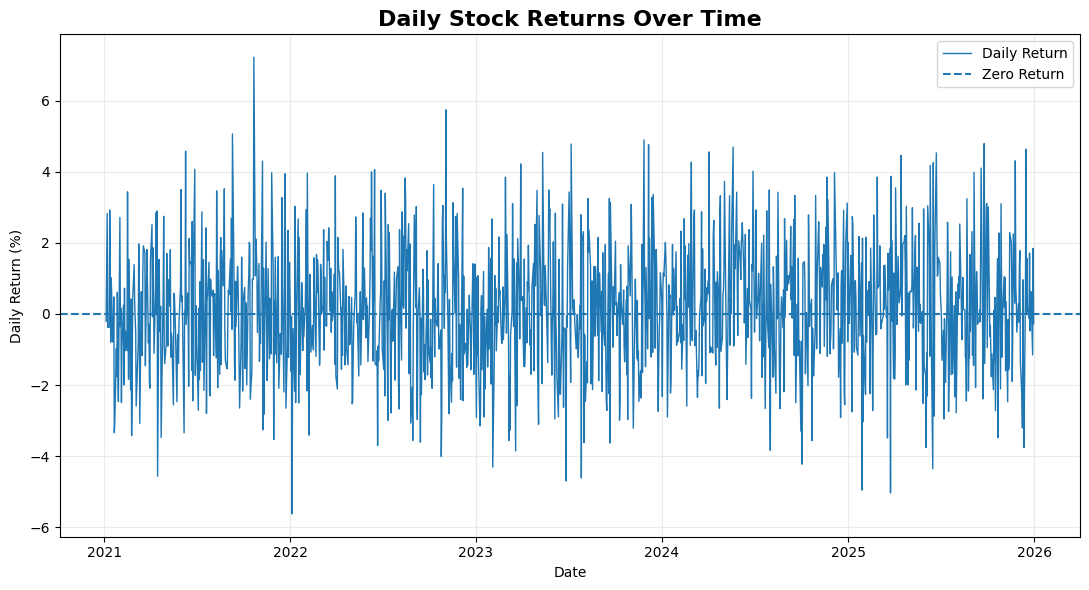


💡 Positive values indicate daily gains, while negative
   values indicate daily declines in the stock price.


In [30]:
# ============================================================
# DAILY RETURNS VISUALIZATION
# ============================================================

print("📈 Visualizing Daily Returns...")
print("─" * 50)

plt.figure(figsize=(11, 6))

plt.plot(
    df["Date"],
    df["Daily_Return"],
    linewidth=1,
    label="Daily Return"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1.5,
    label="Zero Return"
)

plt.title(
    "Daily Stock Returns Over Time",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Daily Return (%)")

plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()

plt.show()

print("\n💡 Positive values indicate daily gains, while negative")
print("   values indicate daily declines in the stock price.")

In [31]:
# ============================================================
# PRICE AND VOLUME RELATIONSHIP
# ============================================================

print("🔍 Analyzing Price and Trading Volume Relationship...")
print("─" * 55)

# Calculate correlation between closing price and volume
price_volume_correlation = df["Close"].corr(df["Volume"])

print(f"\n📊 Price-Volume Correlation : {price_volume_correlation:.3f}")

if price_volume_correlation > 0.5:
    interpretation = "Strong positive relationship"
elif price_volume_correlation > 0:
    interpretation = "Weak positive relationship"
elif price_volume_correlation < -0.5:
    interpretation = "Strong negative relationship"
else:
    interpretation = "Weak or negative relationship"

print(f"📌 Interpretation           : {interpretation}")

print("\n💡 Correlation helps identify whether price and")
print("   trading volume tend to move together.")

print("\n✅ Relationship analysis completed!")

🔍 Analyzing Price and Trading Volume Relationship...
───────────────────────────────────────────────────────

📊 Price-Volume Correlation : 0.026
📌 Interpretation           : Weak positive relationship

💡 Correlation helps identify whether price and
   trading volume tend to move together.

✅ Relationship analysis completed!


📊 Comparing Stock Price with Trading Volume...
───────────────────────────────────────────────────────


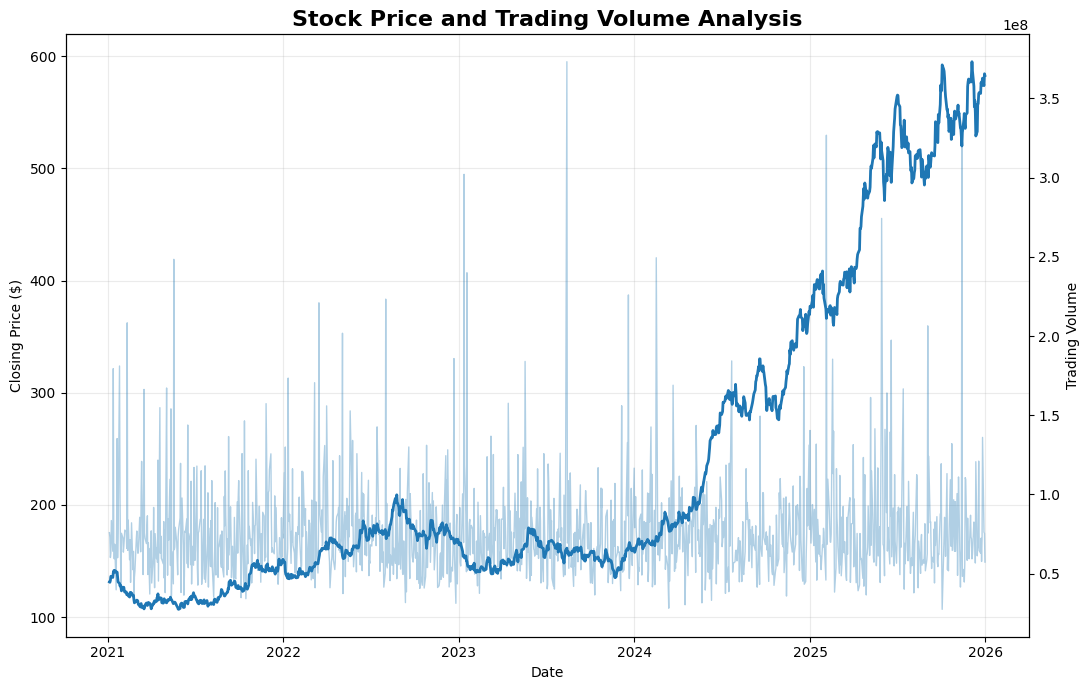


💡 This comparison helps identify periods where
   major price movements occur alongside changes in volume.


In [33]:
# ============================================================
# STOCK PRICE AND TRADING VOLUME
# ============================================================

print("📊 Comparing Stock Price with Trading Volume...")
print("─" * 55)

fig, ax1 = plt.subplots(figsize=(11, 7))

# Closing price
ax1.plot(
    df["Date"],
    df["Close"],
    linewidth=2,
    label="Closing Price"
)

ax1.set_title(
    "Stock Price and Trading Volume Analysis",
    fontsize=16,
    fontweight="bold"
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Closing Price ($)")
ax1.grid(True, alpha=0.25)

# Trading volume on secondary axis
ax2 = ax1.twinx()

ax2.plot(
    df["Date"],
    df["Volume"],
    linewidth=1,
    alpha=0.35,
    label="Trading Volume"
)

ax2.set_ylabel("Trading Volume")

fig.tight_layout()
plt.show()

print("\n💡 This comparison helps identify periods where")
print("   major price movements occur alongside changes in volume.")

In [34]:
# ============================================================
# BEST & WORST TRADING DAYS
# ============================================================

print("🏆 Identifying Best and Worst Trading Days...")
print("─" * 55)

# Find the best trading day
best_day_index = df["Daily_Return"].idxmax()

# Find the worst trading day
worst_day_index = df["Daily_Return"].idxmin()

best_date = df.loc[best_day_index, "Date"]
best_return = df.loc[best_day_index, "Daily_Return"]

worst_date = df.loc[worst_day_index, "Date"]
worst_return = df.loc[worst_day_index, "Daily_Return"]

best_close = df.loc[best_day_index, "Close"]
worst_close = df.loc[worst_day_index, "Close"]

print("\n🚀 Best Trading Day")
print(f"   Date   : {best_date.strftime('%d %B %Y')}")
print(f"   Return : {best_return:.2f}%")
print(f"   Close  : ${best_close:,.2f}")

print("\n📉 Worst Trading Day")
print(f"   Date   : {worst_date.strftime('%d %B %Y')}")
print(f"   Return : {worst_return:.2f}%")
print(f"   Close  : ${worst_close:,.2f}")

print("\n✅ Extreme daily movements identified successfully!")

🏆 Identifying Best and Worst Trading Days...
───────────────────────────────────────────────────────

🚀 Best Trading Day
   Date   : 22 October 2021
   Return : 7.23%
   Close  : $137.79

📉 Worst Trading Day
   Date   : 05 January 2022
   Return : -5.63%
   Close  : $140.53

✅ Extreme daily movements identified successfully!


In [35]:
# ============================================================
# OVERALL STOCK PERFORMANCE
# ============================================================

print("📈 Evaluating Overall Stock Performance...")
print("─" * 55)

# Starting and ending closing prices
starting_price = df["Close"].iloc[0]
ending_price = df["Close"].iloc[-1]

# Calculate overall percentage change
overall_return = ((ending_price - starting_price) / starting_price) * 100

# Calculate total price change
price_change = ending_price - starting_price

print("\n💰 Performance Summary")
print(f"   Starting Price : ${starting_price:,.2f}")
print(f"   Ending Price   : ${ending_price:,.2f}")
print(f"   Price Change   : ${price_change:,.2f}")
print(f"   Total Return   : {overall_return:.2f}%")

if overall_return > 0:
    print("\n📈 Overall Trend : Upward")
elif overall_return < 0:
    print("\n📉 Overall Trend : Downward")
else:
    print("\n➡️ Overall Trend : Stable")

print("\n✅ Overall performance analysis completed!")

📈 Evaluating Overall Stock Performance...
───────────────────────────────────────────────────────

💰 Performance Summary
   Starting Price : $131.23
   Ending Price   : $582.78
   Price Change   : $451.55
   Total Return   : 344.09%

📈 Overall Trend : Upward

✅ Overall performance analysis completed!


In [36]:
# ============================================================
# FINAL INSIGHTS & CONCLUSION
# ============================================================

print("📝 Generating Final Stock Market Insights...")
print("=" * 60)

# Determine overall market direction
if overall_return > 0:
    trend = "an upward"
    performance_text = "gained"
elif overall_return < 0:
    trend = "a downward"
    performance_text = "declined"
else:
    trend = "a stable"
    performance_text = "remained stable"

# Moving average interpretation
latest_ma20 = df["MA_20"].iloc[-1]
latest_ma50 = df["MA_50"].iloc[-1]

if latest_ma20 > latest_ma50:
    ma_signal = "The 20-day moving average is above the 50-day moving average, indicating stronger recent price momentum."
else:
    ma_signal = "The 20-day moving average is below the 50-day moving average, indicating weaker recent price momentum."

# Generate insights
print("\n📌 KEY FINDINGS")
print("─" * 60)

print(
    f"• The stock showed {trend} trend during the analyzed period "
    f"with an overall return of {overall_return:.2f}%."
)

print(
    f"• The stock {performance_text} from "
    f"${starting_price:,.2f} to ${ending_price:,.2f}."
)

print(
    f"• The average daily return was {average_return:.2f}%, "
    f"with daily volatility of {volatility:.2f}%."
)

print(
    f"• The highest daily gain was {best_return:.2f}% "
    f"on {best_date.strftime('%d %B %Y')}."
)

print(
    f"• The largest daily decline was {worst_return:.2f}% "
    f"on {worst_date.strftime('%d %B %Y')}."
)

print(
    f"• The average trading volume was approximately "
    f"{average_volume:,.0f} shares per trading day."
)

print(f"• {ma_signal}")

print(
    f"• The correlation between closing price and trading volume "
    f"was {price_volume_correlation:.3f}."
)

print("\n🎯 CONCLUSION")
print("─" * 60)

print(
    "The analysis provides a clear view of historical stock price "
    "movements, market activity, trends, and volatility. Moving "
    "averages help identify the underlying price trend, while "
    "trading volume provides additional insight into market activity."
)

print("\n✅ Stock Market Analysis completed successfully!")

📝 Generating Final Stock Market Insights...

📌 KEY FINDINGS
────────────────────────────────────────────────────────────
• The stock showed an upward trend during the analyzed period with an overall return of 344.09%.
• The stock gained from $131.23 to $582.78.
• The average daily return was 0.13%, with daily volatility of 1.78%.
• The highest daily gain was 7.23% on 22 October 2021.
• The largest daily decline was -5.63% on 05 January 2022.
• The average trading volume was approximately 76,380,066 shares per trading day.
• The 20-day moving average is above the 50-day moving average, indicating stronger recent price momentum.
• The correlation between closing price and trading volume was 0.026.

🎯 CONCLUSION
────────────────────────────────────────────────────────────
The analysis provides a clear view of historical stock price movements, market activity, trends, and volatility. Moving averages help identify the underlying price trend, while trading volume provides additional insight 

🔗 Analyzing Relationships Between Stock Indicators...
───────────────────────────────────────────────────────


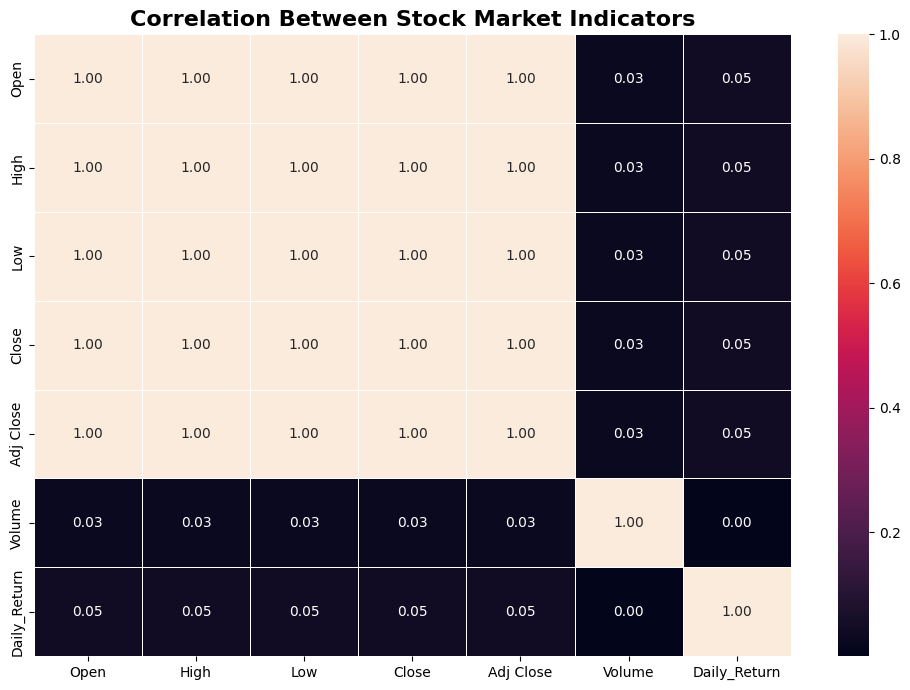


💡 The heatmap shows how strongly different stock indicators
   are related to each other.

✅ Correlation analysis completed!


In [37]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

print("🔗 Analyzing Relationships Between Stock Indicators...")
print("─" * 55)

# Select numerical indicators
correlation_data = df[
    ["Open", "High", "Low", "Close", "Adj Close", "Volume", "Daily_Return"]
]

# Calculate correlation matrix
correlation_matrix = correlation_data.corr()

# Visualize correlations
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Between Stock Market Indicators",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

print("\n💡 The heatmap shows how strongly different stock indicators")
print("   are related to each other.")
print("\n✅ Correlation analysis completed!")

In [38]:
# ============================================================
# FINAL DATASET SUMMARY
# ============================================================

print("📋 Preparing Final Dataset Summary...")
print("─" * 50)

# Display the final dataset structure
print("\n📊 Final Dataset Shape:")
print(f"   Records : {df.shape[0]:,}")
print(f"   Columns : {df.shape[1]}")

print("\n🗂️ Final Columns:")
for column in df.columns:
    print(f"   • {column}")

print("\n📅 Analysis Period:")
print(f"   From : {df['Date'].min().strftime('%d %B %Y')}")
print(f"   To   : {df['Date'].max().strftime('%d %B %Y')}")

print("\n✅ Dataset is ready for final project presentation!")

📋 Preparing Final Dataset Summary...
──────────────────────────────────────────────────

📊 Final Dataset Shape:
   Records : 1,303
   Columns : 10

🗂️ Final Columns:
   • Date
   • Open
   • High
   • Low
   • Close
   • Adj Close
   • Volume
   • MA_20
   • MA_50
   • Daily_Return

📅 Analysis Period:
   From : 04 January 2021
   To   : 31 December 2025

✅ Dataset is ready for final project presentation!


# 📈 Stock Market Analysis

### Historical Stock Price Trends & Market Activity

This project analyzes historical stock market data to identify price trends, patterns, volatility, moving averages, and trading activity.

**Key Areas of Analysis:**

* Historical Closing Price Trends
* 20-Day and 50-Day Moving Averages
* Trading Volume Analysis
* Daily Returns and Volatility
* Price & Volume Relationship
* Best and Worst Trading Days
* Correlation Analysis
* Overall Stock Performance

**Tools & Libraries:**
Python • Pandas • NumPy • Matplotlib • Seaborn


# 🎯 Final Summary

## Key Insights

The Stock Market Analysis project examined historical stock price movements and trading activity over the selected period.

### 📈 Price Trend

The closing price analysis helped identify the overall direction and major movements in the stock price.

### 📊 Moving Averages

The 20-day and 50-day moving averages were used to smooth short-term fluctuations and understand the underlying price trend.

### 📦 Trading Volume

Trading volume analysis highlighted periods of higher and lower market activity.

### ⚡ Daily Returns

Daily returns helped measure short-term gains, losses, and price volatility.

### 🔗 Correlation

Correlation analysis provided an overview of the relationships between different stock market indicators.

## Conclusion

This analysis demonstrates how Python-based data analysis and visualization techniques can be used to understand historical stock market behavior. The combination of price trends, moving averages, trading volume, daily returns, and correlation analysis provides a comprehensive view of the stock's historical performance.

> **Note:** This project focuses on historical data analysis and does not provide financial advice or predict future stock prices.
